## Imports and setup

In [1]:
!pip install networkx


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import seaborn as sns
import networkx as nx
import warnings
import joblib
import os
from collections import defaultdict
warnings.filterwarnings('ignore')

# Check networkx version
print(f"NetworkX version : {nx.__version__}")
print("All libraries imported!")

NetworkX version : 3.6.1
All libraries imported!


## Load dataset

In [3]:
# Load featured dataset from Notebook 5
# We need original account IDs and transaction details
# to build the graph

df = pd.read_csv(r"C:\Users\tjain\Downloads\HI-Small_Trans.csv")

print("Dataset loaded!")
print(f"Shape          : {df.shape}")
print(f"Fraud rows     : {df['Is Laundering'].sum():,}")
print(f"Normal rows    : {(df['Is Laundering']==0).sum():,}")

# For graph building we work with a sample
# because 5 million edges would be too slow to visualise
# We use ALL data for feature calculation
# but a sample for visualisation

print(f"\nUsing full dataset for feature calculation")
print(f"Using sample for visualisation")

Dataset loaded!
Shape          : (5078336, 32)
Fraud rows     : 5,177
Normal rows    : 5,073,159

Using full dataset for feature calculation
Using sample for visualisation


In [4]:
required_cols = [
    'Sender_Account_Encoded',
    'Receiver_Account_Encoded',
    'Amount_Paid_Log',
    'Is Laundering'
]

missing = [c for c in required_cols if c not in df.columns]

if missing:
    print("Missing columns:", missing)
else:
    print("All required columns are available.")

Missing columns: ['Amount_Paid_Log']


In [5]:
df.columns.tolist()

['Hour',
 'Day',
 'DayOfWeek',
 'IsWeekend',
 'Sender Bank ID',
 'Receiver Bank ID',
 'is_cross_bank',
 'Sender_Account_Encoded',
 'Receiver_Account_Encoded',
 'is_self_transfer',
 'Amount Paid',
 'Amount Received',
 'amount_vs_account_median',
 'is_currency_mismatch',
 'is_amount_outlier_iqr',
 'is_amount_outlier_zscore',
 'is_account_level_outlier',
 'is_high_velocity',
 'outlier_score',
 'is_outlier',
 'txn_count_per_sender_hour',
 'txn_count_per_sender_day',
 'fmt_ACH',
 'fmt_Bitcoin',
 'fmt_Cash',
 'fmt_Cheque',
 'fmt_Credit Card',
 'fmt_Reinvestment',
 'fmt_Wire',
 'Payment_Currency_Encoded',
 'Receiving_Currency_Encoded',
 'Is Laundering']

In [6]:
import numpy as np

if 'Amount_Paid_Log' not in df.columns:
    df['Amount_Paid_Log'] = np.log1p(df['Amount Paid'])

print("Amount_Paid_Log created successfully!")

Amount_Paid_Log created successfully!


## Build the full transaction graph

In [7]:
# ============================================================
# BUILD TRANSACTION GRAPH
# ============================================================
# Every ACCOUNT is a NODE
# Every TRANSACTION is a DIRECTED EDGE
# Edge has properties: amount, timestamp, is_fraud
#
# Directed because money flows ONE WAY
# A → B means A sent money to B
# ============================================================

print("Building transaction graph...")
print("This may take 2-3 minutes for 5M transactions...")

# Create directed graph
# DiGraph = Directed Graph (edges have direction)
G = nx.DiGraph()

# Add edges from dataframe
# Each row is one transaction = one edge
edges = list(zip(
    df['Sender_Account_Encoded'].astype(str),
    df['Receiver_Account_Encoded'].astype(str),
    df['Amount_Paid_Log'],
    df['Is Laundering']
))

# Add edges with attributes
for sender, receiver, amount, is_fraud in edges:
    if G.has_edge(sender, receiver):
        # If edge exists already add to it
        G[sender][receiver]['weight']      += amount
        G[sender][receiver]['txn_count']   += 1
        G[sender][receiver]['fraud_count'] += int(is_fraud)
    else:
        G.add_edge(
            sender, receiver,
            weight      = amount,
            txn_count   = 1,
            fraud_count = int(is_fraud)
        )

print(f"\nGraph built!")
print(f"Total nodes (accounts)    : {G.number_of_nodes():,}")
print(f"Total edges (transactions): {G.number_of_edges():,}")
print(f"Graph density             : {nx.density(G):.8f}")
print(f"Is directed               : {G.is_directed()}")

Building transaction graph...
This may take 2-3 minutes for 5M transactions...

Graph built!
Total nodes (accounts)    : 515,080
Total edges (transactions): 1,015,736
Graph density             : 0.00000383
Is directed               : True


## Graph Metrices

In [8]:
# ============================================================
# IN-DEGREE AND OUT-DEGREE
# ============================================================
# In-degree  = number of accounts sending TO this account
#              High in-degree = money COLLECTOR = potential mule
#
# Out-degree = number of accounts this account sends TO
#              High out-degree = money DISTRIBUTOR = potential launderer
#
# Both high = money PASSER = classic mule behaviour
# ============================================================

print("Calculating degree metrics...")

# In-degree = how many unique senders send to this account
in_degree  = dict(G.in_degree())
out_degree = dict(G.out_degree())

# Weighted degree = total transaction amount
in_degree_weighted  = dict(G.in_degree(weight='weight'))
out_degree_weighted = dict(G.out_degree(weight='weight'))

# Map back to dataframe
df['graph_in_degree']  = df['Receiver_Account_Encoded'].astype(str).map(in_degree).fillna(0)
df['graph_out_degree'] = df['Sender_Account_Encoded'].astype(str).map(out_degree).fillna(0)

df['graph_in_degree_weighted']  = df['Receiver_Account_Encoded'].astype(str).map(in_degree_weighted).fillna(0)
df['graph_out_degree_weighted'] = df['Sender_Account_Encoded'].astype(str).map(out_degree_weighted).fillna(0)

# Total degree = in + out
df['graph_total_degree'] = df['graph_in_degree'] + df['graph_out_degree']

# Degree ratio = in / out
# > 1 = receives from more than sends to = collector
# < 1 = sends to more than receives from = distributor
df['graph_degree_ratio'] = (
    df['graph_in_degree'] /
    (df['graph_out_degree'] + 0.001)
)

print("Degree metrics calculated!")
print("\nFraud vs Normal — Degree comparison:")
degree_cols = [
    'graph_in_degree',
    'graph_out_degree',
    'graph_total_degree',
    'graph_degree_ratio'
]
print(df.groupby('Is Laundering')[degree_cols].mean().round(2))

Calculating degree metrics...
Degree metrics calculated!

Fraud vs Normal — Degree comparison:
               graph_in_degree  graph_out_degree  graph_total_degree  \
Is Laundering                                                          
0                         3.83            700.47              704.30   
1                         6.54            998.97             1005.51   

               graph_degree_ratio  
Is Laundering                      
0                            1.35  
1                            2.16  


## Peak Range score

In [9]:
# ============================================================
# PAGERANK SCORE
# ============================================================
# PageRank was invented by Google to rank web pages
# In AML it tells us: how CENTRAL is this account
# in the transaction network?
#
# High PageRank = money flows THROUGH this account
# a lot — it is a hub in the network
#
# A normal person has low PageRank
# A money laundering hub has very high PageRank
# because many accounts send and receive through it
# ============================================================

print("Calculating PageRank scores...")
print("This takes 1-2 minutes...")

pagerank_scores = nx.pagerank(
    G,
    alpha   = 0.85,    # damping factor (standard value)
    weight  = 'weight' # use transaction amount as weight
)

# Map to dataframe
df['graph_pagerank_sender']   = df['Sender_Account_Encoded'].astype(str).map(pagerank_scores).fillna(0)
df['graph_pagerank_receiver'] = df['Receiver_Account_Encoded'].astype(str).map(pagerank_scores).fillna(0)

# Max pagerank of sender or receiver
df['graph_pagerank_max'] = df[
    ['graph_pagerank_sender', 'graph_pagerank_receiver']
].max(axis=1)

print("PageRank calculated!")
print(f"\nMax PageRank score  : {max(pagerank_scores.values()):.6f}")
print(f"Mean PageRank score : {np.mean(list(pagerank_scores.values())):.6f}")

print("\nFraud vs Normal — PageRank:")
print(df.groupby('Is Laundering')[
    ['graph_pagerank_sender','graph_pagerank_receiver','graph_pagerank_max']
].mean().round(6))

Calculating PageRank scores...
This takes 1-2 minutes...
PageRank calculated!

Max PageRank score  : 0.000160
Mean PageRank score : 0.000002

Fraud vs Normal — PageRank:
               graph_pagerank_sender  graph_pagerank_receiver  \
Is Laundering                                                   
0                           0.000009                 0.000003   
1                           0.000013                 0.000005   

               graph_pagerank_max  
Is Laundering                      
0                        0.000011  
1                        0.000016  


## Fan-in and Fan-out pattern at graph level

In [10]:
# ============================================================
# FAN-IN AND FAN-OUT PATTERN
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# FAN-IN  = MANY accounts → ONE account
# FAN-OUT = ONE account → MANY accounts
#
# We measure this using unique connected accounts.
# This is better than simply counting transactions.
# ------------------------------------------------------------

print("Creating fan-in / fan-out graph features...")

# ------------------------------------------------------------
# 1. Make sure account columns exist
# ------------------------------------------------------------

sender_col = 'Sender_Account_Encoded'
receiver_col = 'Receiver_Account_Encoded'

if sender_col not in df.columns:
    raise KeyError(f"Missing column: {sender_col}")

if receiver_col not in df.columns:
    raise KeyError(f"Missing column: {receiver_col}")


# ------------------------------------------------------------
# 2. Calculate IN-DEGREE
#
# For each receiver:
# How many UNIQUE sender accounts send money to it?
# ------------------------------------------------------------

in_degree = (
    df.groupby(receiver_col)[sender_col]
      .nunique()
      .to_dict()
)


# ------------------------------------------------------------
# 3. Calculate OUT-DEGREE
#
# For each sender:
# How many UNIQUE receiver accounts does it send money to?
# ------------------------------------------------------------

out_degree = (
    df.groupby(sender_col)[receiver_col]
      .nunique()
      .to_dict()
)


print(f"Number of accounts with incoming connections: {len(in_degree):,}")
print(f"Number of accounts with outgoing connections: {len(out_degree):,}")


# ------------------------------------------------------------
# 4. Normalise degree values
# ------------------------------------------------------------

max_in = max(in_degree.values()) if in_degree else 1
max_out = max(out_degree.values()) if out_degree else 1

fan_in_graph = {
    node: degree / max_in
    for node, degree in in_degree.items()
}

fan_out_graph = {
    node: degree / max_out
    for node, degree in out_degree.items()
}


# ------------------------------------------------------------
# 5. Add graph fan-in / fan-out scores to transactions
# ------------------------------------------------------------

df['graph_fan_in_score'] = (
    df[receiver_col]
    .map(fan_in_graph)
    .fillna(0)
)

df['graph_fan_out_score'] = (
    df[sender_col]
    .map(fan_out_graph)
    .fillna(0)
)


# ------------------------------------------------------------
# 6. Add raw graph degrees
# ------------------------------------------------------------

df['graph_in_degree'] = (
    df[receiver_col]
    .map(in_degree)
    .fillna(0)
)

df['graph_out_degree'] = (
    df[sender_col]
    .map(out_degree)
    .fillna(0)
)


# ------------------------------------------------------------
# 7. Calculate HIGH-IN / HIGH-OUT thresholds
#
# Top 10% of accounts are considered high.
# ------------------------------------------------------------

in_values = np.array(list(in_degree.values()))
out_values = np.array(list(out_degree.values()))

in_threshold = np.percentile(in_values, 90) if len(in_values) > 0 else 0
out_threshold = np.percentile(out_values, 90) if len(out_values) > 0 else 0

print(f"\nHigh fan-in threshold  : {in_threshold:.2f}")
print(f"High fan-out threshold : {out_threshold:.2f}")


# ------------------------------------------------------------
# 8. Classify fan-in / fan-out pattern
# ------------------------------------------------------------

def classify_fan_pattern(in_deg, out_deg):

    high_in = in_deg > in_threshold
    high_out = out_deg > out_threshold

    if high_in and high_out:
        return 3       # Mule / pass-through

    elif high_in and not high_out:
        return 2       # Collector / fan-in

    elif not high_in and high_out:
        return 1       # Distributor / fan-out

    else:
        return 0       # Normal


# ------------------------------------------------------------
# 9. Apply classification to SENDER account
# ------------------------------------------------------------

sender_in_deg = (
    df[sender_col]
    .map(in_degree)
    .fillna(0)
)

sender_out_deg = (
    df[sender_col]
    .map(out_degree)
    .fillna(0)
)


df['graph_fan_pattern'] = [
    classify_fan_pattern(i, o)
    for i, o in zip(sender_in_deg, sender_out_deg)
]


# ------------------------------------------------------------
# 10. Pattern labels
# ------------------------------------------------------------

pattern_labels = {
    0: 'Normal',
    1: 'Distributor (Fan-out)',
    2: 'Collector (Fan-in)',
    3: 'Mule (Both)'
}


# ------------------------------------------------------------
# 11. Pattern distribution
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("FAN PATTERN DISTRIBUTION")
print("=" * 60)

pattern_counts = (
    df['graph_fan_pattern']
    .value_counts()
    .sort_index()
)

for code, count in pattern_counts.items():

    label = pattern_labels.get(code, 'Unknown')

    print(
        f"  {label:25}: {count:,}"
    )


# ------------------------------------------------------------
# 12. Fraud rate by fan pattern
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("FRAUD RATE BY FAN PATTERN")
print("=" * 60)

target_col = 'Is Laundering'

if target_col in df.columns:

    fan_fraud = (
        df.groupby('graph_fan_pattern')[target_col]
          .mean()
          .mul(100)
    )

    for code, rate in fan_fraud.items():

        label = pattern_labels.get(code, 'Unknown')

        bar = '█' * min(int(rate * 5), 50)

        print(
            f"  {label:25}: "
            f"{rate:.4f}%  {bar}"
        )

else:
    print(f"WARNING: '{target_col}' column not found.")


# ------------------------------------------------------------
# 13. Final verification
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("FAN-IN / FAN-OUT FEATURES CREATED")
print("=" * 60)

print("\nNew columns:")

print([
    'graph_fan_in_score',
    'graph_fan_out_score',
    'graph_in_degree',
    'graph_out_degree',
    'graph_fan_pattern'
])

print("\nData shape:", df.shape)

print("\nMissing values:")
print(
    df[
        [
            'graph_fan_in_score',
            'graph_fan_out_score',
            'graph_in_degree',
            'graph_out_degree',
            'graph_fan_pattern'
        ]
    ].isna().sum()
)

Creating fan-in / fan-out graph features...
Number of accounts with incoming connections: 420,636
Number of accounts with outgoing connections: 496,995

High fan-in threshold  : 4.00
High fan-out threshold : 4.00

FAN PATTERN DISTRIBUTION
  Normal                   : 2,604,096
  Distributor (Fan-out)    : 1,635,794
  Collector (Fan-in)       : 232,578
  Mule (Both)              : 605,868

FRAUD RATE BY FAN PATTERN
  Normal                   : 0.0998%  
  Distributor (Fan-out)    : 0.0611%  
  Collector (Fan-in)       : 0.1681%  
  Mule (Both)              : 0.1961%  

FAN-IN / FAN-OUT FEATURES CREATED

New columns:
['graph_fan_in_score', 'graph_fan_out_score', 'graph_in_degree', 'graph_out_degree', 'graph_fan_pattern']

Data shape: (5078336, 45)

Missing values:
graph_fan_in_score     0
graph_fan_out_score    0
graph_in_degree        0
graph_out_degree       0
graph_fan_pattern      0
dtype: int64


## Circular transaction detection

In [11]:
# ============================================================
# CIRCULAR TRANSACTION PATTERN
# ============================================================
# Circular flow = money goes in a circle and comes back
# to the original sender
#
# Example:
# A → B → C → D → A  (money returned to A)
#
# This is a classic LAYERING technique
# Criminal sends money through many accounts
# to make it look like legitimate transactions
# then collects it back cleaned
#
# We detect cycles in the graph
# ============================================================

print("Detecting circular transaction patterns...")
print("Working on a sample for speed...")

# Work on a subgraph for cycle detection
# Full 5M edge graph would take too long
# We sample the most suspicious nodes
# (highest degree accounts)

# Get top 5000 nodes by total degree
top_nodes = sorted(
    G.nodes(),
    key=lambda n: G.in_degree(n) + G.out_degree(n),
    reverse=True
)[:5000]

G_sample = G.subgraph(top_nodes).copy()

print(f"Sample graph: {G_sample.number_of_nodes()} nodes, {G_sample.number_of_edges()} edges")

# ── Find simple cycles ────────────────────────────────────
# Simple cycle = path that starts and ends at same node
# without repeating any node

cycles_found = []
cycle_nodes  = set()

try:
    for cycle in nx.simple_cycles(G_sample):
        if len(cycle) >= 2:   # minimum 2 hops
            cycles_found.append(cycle)
            cycle_nodes.update(cycle)
        if len(cycles_found) >= 1000:  # cap at 1000
            break
except Exception as e:
    print(f"Cycle detection note: {e}")

print(f"\nCircular patterns found : {len(cycles_found):,}")
print(f"Accounts in cycles      : {len(cycle_nodes):,}")

# ── Cycle length distribution ─────────────────────────────
if cycles_found:
    cycle_lengths = [len(c) for c in cycles_found]
    print(f"\nCycle length distribution:")
    from collections import Counter
    length_dist = Counter(cycle_lengths)
    for length, count in sorted(length_dist.items()):
        print(f"  {length}-hop cycle : {count:,}")

# ── Map cycle membership back to dataframe ─────────────────
df['is_in_cycle'] = (
    df['Sender_Account_Encoded'].astype(str).isin(cycle_nodes) |
    df['Receiver_Account_Encoded'].astype(str).isin(cycle_nodes)
).astype(int)

print(f"\nTransactions involving cycle accounts: {df['is_in_cycle'].sum():,}")
print(f"Fraud rate in cycle transactions     : {df[df['is_in_cycle']==1]['Is Laundering'].mean()*100:.4f}%")
print(f"Fraud rate overall                   : {df['Is Laundering'].mean()*100:.4f}%")

Detecting circular transaction patterns...
Working on a sample for speed...
Sample graph: 5000 nodes, 6226 edges

Circular patterns found : 812
Accounts in cycles      : 830

Cycle length distribution:
  2-hop cycle : 519
  3-hop cycle : 160
  4-hop cycle : 45
  5-hop cycle : 30
  6-hop cycle : 23
  7-hop cycle : 18
  8-hop cycle : 12
  9-hop cycle : 5

Transactions involving cycle accounts: 40,402
Fraud rate in cycle transactions     : 0.4851%
Fraud rate overall                   : 0.1019%


## Community detection

In [12]:
# ============================================================
# COMMUNITY DETECTION
# ============================================================
# A community = group of accounts that transact
# mostly WITH EACH OTHER and rarely with outsiders
#
# In money laundering:
# Criminal networks form tight communities
# They move money within the group to layer it
#
# We use the Louvain-like algorithm available
# in NetworkX to find these communities
# ============================================================

print("Detecting transaction communities...")

# Convert to undirected for community detection
G_undirected = G_sample.to_undirected()

# Use greedy modularity communities
# This is fast and works well on financial networks
communities = list(
    nx.community.greedy_modularity_communities(
        G_undirected,
        weight='weight'
    )
)

print(f"\nCommunities found : {len(communities):,}")
print(f"\nTop 10 largest communities:")
for i, community in enumerate(
    sorted(communities, key=len, reverse=True)[:10]
):
    print(f"  Community {i+1:2}: {len(community):,} accounts")

# ── Map community ID to each node ─────────────────────────
node_to_community = {}
for comm_id, community in enumerate(communities):
    for node in community:
        node_to_community[node] = comm_id

# ── Calculate fraud rate per community ────────────────────
# Which communities have highest fraud concentration?

# Map community to transactions
df['graph_community_id'] = df['Sender_Account_Encoded'].astype(str).map(
    node_to_community
).fillna(-1).astype(int)

# Calculate fraud rate per community
community_fraud_rate = df.groupby(
    'graph_community_id'
)['Is Laundering'].mean()

# Map fraud rate back
df['graph_community_fraud_rate'] = df['graph_community_id'].map(
    community_fraud_rate
).fillna(0)

# Flag suspicious communities (fraud rate > 2x average)
avg_fraud_rate = df['Is Laundering'].mean()
df['is_suspicious_community'] = (
    df['graph_community_fraud_rate'] > avg_fraud_rate * 2
).astype(int)

print(f"\nSuspicious communities detected: {df['is_suspicious_community'].sum():,} transactions")
print(f"Fraud rate in suspicious communities: {df[df['is_suspicious_community']==1]['Is Laundering'].mean()*100:.4f}%")

Detecting transaction communities...

Communities found : 3,351

Top 10 largest communities:
  Community  1: 171 accounts
  Community  2: 66 accounts
  Community  3: 56 accounts
  Community  4: 39 accounts
  Community  5: 35 accounts
  Community  6: 34 accounts
  Community  7: 32 accounts
  Community  8: 32 accounts
  Community  9: 30 accounts
  Community 10: 29 accounts

Suspicious communities detected: 62,212 transactions
Fraud rate in suspicious communities: 1.4145%


## Potential mule deection at graph level

In [13]:
# ============================================================
# GRAPH-LEVEL MULE ACCOUNT DETECTION
# ============================================================
# Combines graph metrics to identify mule accounts
# More accurate than feature-based detection alone
# because it uses the actual network structure
# ============================================================

# ── Mule criteria using graph metrics ─────────────────────

# High in-degree  = receives from many accounts
high_in_degree = pd.Series(
    df['Receiver_Account_Encoded'].astype(str).map(in_degree).fillna(0)
) > np.percentile(list(in_degree.values()), 85)

# High out-degree = sends to many accounts
high_out_degree = df['graph_out_degree'] > np.percentile(
    list(out_degree.values()), 85
)

# High PageRank = central in network
high_pagerank = df['graph_pagerank_sender'] > df['graph_pagerank_sender'].quantile(0.85)

# In cycle = involved in circular flow
in_cycle = df['is_in_cycle'] == 1

# In suspicious community
in_bad_community = df['is_suspicious_community'] == 1

# ── Graph mule score ──────────────────────────────────────
df['graph_mule_score'] = (
    high_in_degree.values.astype(int)  +
    high_out_degree.astype(int)        +
    high_pagerank.astype(int)          +
    in_cycle.astype(int)               +
    in_bad_community.astype(int)
)

# Flag as graph mule if score >= 3
df['graph_is_mule'] = (df['graph_mule_score'] >= 3).astype(int)

print("Graph mule detection complete!")
print(f"\nGraph mule score distribution:")
print(df['graph_mule_score'].value_counts().sort_index())

print(f"\nPotential mules (graph): {df['graph_is_mule'].sum():,}")
print(f"\nFraud rate by graph mule score:")
mule_fraud = df.groupby('graph_mule_score')['Is Laundering'].mean() * 100
for score, rate in mule_fraud.items():
    bar = '█' * int(rate * 5)
    print(f"  Score {score}: {rate:.4f}%  {bar}")

Graph mule detection complete!

Graph mule score distribution:
graph_mule_score
0    1955123
1    2578932
2     489297
3      54819
4        165
Name: count, dtype: int64

Potential mules (graph): 54,984

Fraud rate by graph mule score:
  Score 0: 0.0976%  
  Score 1: 0.0619%  
  Score 2: 0.2504%  █
  Score 3: 0.8045%  ████
  Score 4: 3.6364%  ██████████████████


## Additional graph Metrices

In [14]:
# ============================================================
# ADDITIONAL GRAPH METRICS
# ============================================================
# Betweenness centrality = how often does this account
#   sit on the SHORTEST PATH between two other accounts?
#   High = account is a bridge/gateway in the network
#
# Clustering coefficient = how tightly connected are
#   this account's neighbours to each other?
#   High = account is in a tight-knit group
# ============================================================

print("Calculating additional graph metrics...")
print("Working on sample graph...")

# ── Betweenness centrality ────────────────────────────────
# Measures how often account is a bridge
# Expensive to compute — use sample
betweenness = nx.betweenness_centrality(
    G_sample,
    k=500,         # use 500 random samples for speed
    weight='weight',
    normalized=True
)

df['graph_betweenness'] = df['Sender_Account_Encoded'].astype(str).map(
    betweenness
).fillna(0)

# ── Clustering coefficient ────────────────────────────────
# How tightly knit is the neighbourhood?
clustering = nx.clustering(
    G_undirected,
    weight='weight'
)

df['graph_clustering'] = df['Sender_Account_Encoded'].astype(str).map(
    clustering
).fillna(0)

# ── Closeness centrality ──────────────────────────────────
# How close is this account to all other accounts?
# High = account can reach everyone quickly
closeness = nx.closeness_centrality(
    G_sample,
    distance='weight'
)

df['graph_closeness'] = df['Sender_Account_Encoded'].astype(str).map(
    closeness
).fillna(0)

# ── Transaction reciprocity ───────────────────────────────
# Does A send to B AND B send back to A?
# Mutual transfers can be suspicious (circular)
reciprocity_dict = {}
for u, v in G.edges():
    reciprocity_dict[(u,v)] = 1 if G.has_edge(v, u) else 0

df['graph_is_reciprocal'] = [
    reciprocity_dict.get(
        (str(s), str(r)), 0
    )
    for s, r in zip(
        df['Sender_Account_Encoded'],
        df['Receiver_Account_Encoded']
    )
]

print("Additional metrics calculated!")
print("\nFraud vs Normal:")
extra_cols = [
    'graph_betweenness',
    'graph_clustering',
    'graph_closeness',
    'graph_is_reciprocal'
]
print(df.groupby('Is Laundering')[extra_cols].mean().round(6))

Calculating additional graph metrics...
Working on sample graph...
Additional metrics calculated!

Fraud vs Normal:
               graph_betweenness  graph_clustering  graph_closeness  \
Is Laundering                                                         
0                            0.0          0.000063         0.000000   
1                            0.0          0.000384         0.000002   

               graph_is_reciprocal  
Is Laundering                       
0                         0.118227  
1                         0.089820  


## Graph risk score

In [15]:
# ============================================================
# COMBINED GRAPH RISK SCORE
# ============================================================
# Combines all graph signals into one master score
# This score will be used by the Risk Scoring Engine
# in Notebook 10
# ============================================================

df['graph_risk_score'] = (
    # Degree signals
    (df['graph_in_degree']  > df['graph_in_degree'].quantile(0.90)).astype(int)  +
    (df['graph_out_degree'] > df['graph_out_degree'].quantile(0.90)).astype(int) +

    # PageRank signal
    (df['graph_pagerank_max'] > df['graph_pagerank_max'].quantile(0.90)).astype(int) +

    # Pattern signals
    (df['graph_fan_pattern'] == 3).astype(int) * 2 +  # mule pattern = 2 points
    (df['graph_fan_pattern'] >= 1).astype(int)      +  # any pattern = 1 point

    # Cycle and community
    df['is_in_cycle'].fillna(0)              +
    df['is_suspicious_community'].fillna(0)  +

    # Mule score
    (df['graph_mule_score'] >= 3).astype(int) +

    # Centrality signals
    (df['graph_betweenness'] > df['graph_betweenness'].quantile(0.90)).astype(int) +

    # Reciprocal transfer
    df['graph_is_reciprocal'].fillna(0)
)

print("Graph risk score created!")
print(f"\nMax possible score : 11")
print(f"\nScore distribution:")
print(df['graph_risk_score'].value_counts().sort_index())

print(f"\nFraud rate by graph risk score:")
graph_fraud = df.groupby('graph_risk_score')['Is Laundering'].mean() * 100
for score, rate in graph_fraud.items():
    bar = '█' * int(rate * 5)
    print(f"  Score {score:2}: {rate:.4f}%  {bar}")

Graph risk score created!

Max possible score : 11

Score distribution:
graph_risk_score
0    1947304
1    2175289
2     294446
3     182617
4      49916
5     360561
6      22749
7      29648
8      15208
9        598
Name: count, dtype: int64

Fraud rate by graph risk score:
  Score  0: 0.0702%  
  Score  1: 0.0558%  
  Score  2: 0.3355%  █
  Score  3: 0.2273%  █
  Score  4: 0.3806%  █
  Score  5: 0.2061%  █
  Score  6: 0.5099%  ██
  Score  7: 0.3103%  █
  Score  8: 0.3222%  █
  Score  9: 0.6689%  ███


## Main graph visualization

Building graph visualisation...
Visualisation graph: 100 nodes, 158 edges


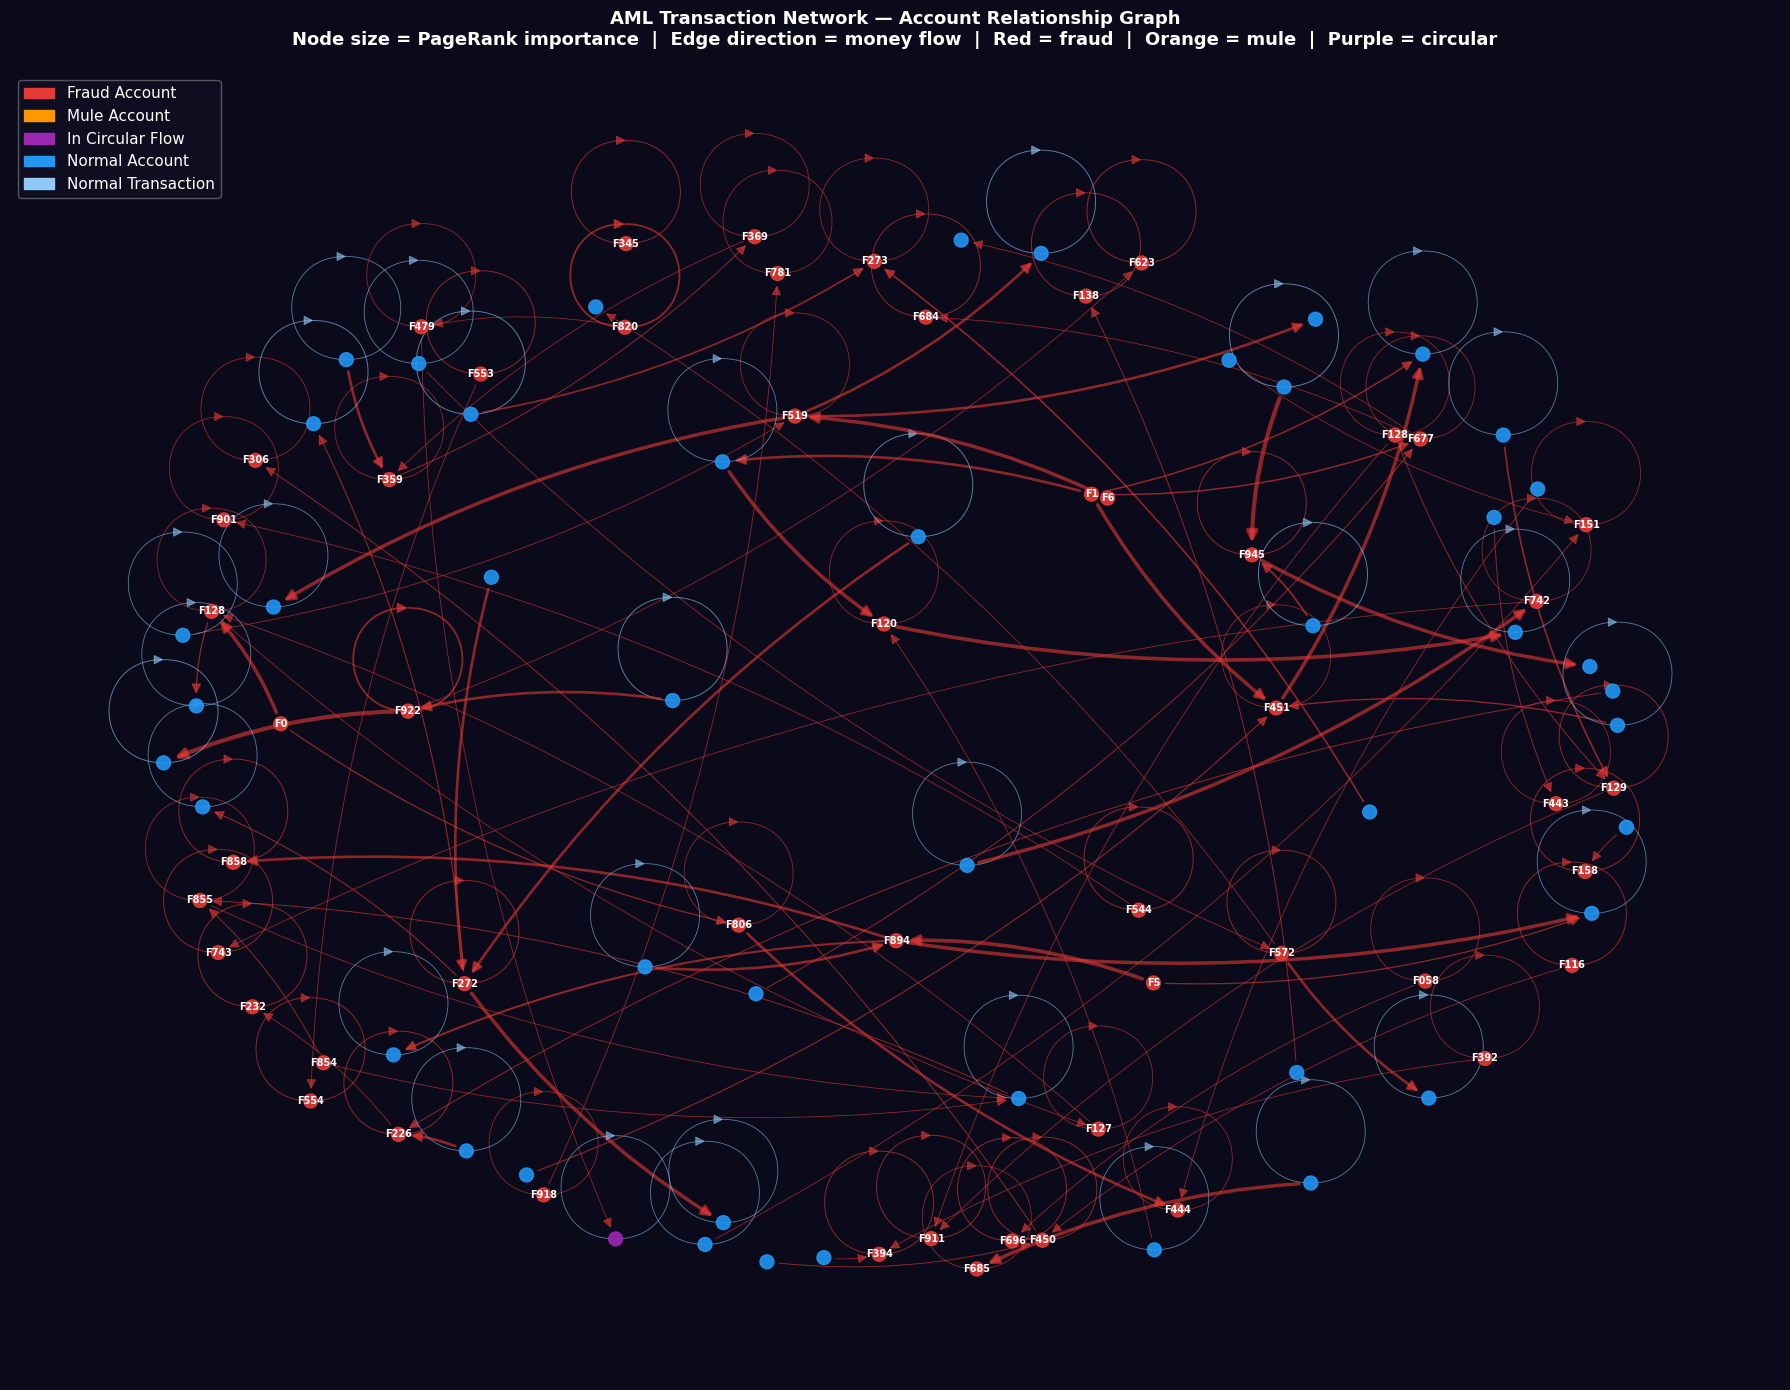

Main graph saved as graph_network.png


In [16]:
# ============================================================
# MAIN GRAPH VISUALISATION
# ============================================================
# Visualise a focused subgraph showing:
# - Red nodes    = fraud accounts
# - Orange nodes = mule accounts
# - Blue nodes   = normal accounts
# - Edge color   = transaction type
# - Node size    = PageRank (importance in network)
# ============================================================

print("Building graph visualisation...")

# ── Sample focused subgraph for visualisation ─────────────
# Take fraud accounts and their 2-hop neighbours
# This gives us the most interesting part of the graph

# Get fraud account IDs
fraud_accounts = set(
    df[df['Is Laundering']==1]['Sender_Account_Encoded'].astype(str).unique()
) | set(
    df[df['Is Laundering']==1]['Receiver_Account_Encoded'].astype(str).unique()
)

# Limit to 30 fraud accounts for clarity
fraud_sample = list(fraud_accounts)[:30]

# Get their direct neighbours
viz_nodes = set(fraud_sample)
for node in fraud_sample:
    if node in G:
        viz_nodes.update(list(G.predecessors(node))[:3])
        viz_nodes.update(list(G.successors(node))[:3])

# Build visualisation subgraph
G_viz = G.subgraph(list(viz_nodes)[:100]).copy()

print(f"Visualisation graph: {G_viz.number_of_nodes()} nodes, {G_viz.number_of_edges()} edges")

# ── Node properties ───────────────────────────────────────

# Get fraud account set for colouring
fraud_set = set(
    df[df['Is Laundering']==1]['Sender_Account_Encoded'].astype(str)
) | set(
    df[df['Is Laundering']==1]['Receiver_Account_Encoded'].astype(str)
)

mule_set = set(
    df[df['graph_is_mule']==1]['Sender_Account_Encoded'].astype(str)
)

cycle_set = cycle_nodes

# Node colours
node_colors = []
for node in G_viz.nodes():
    if node in fraud_set:
        node_colors.append('#E53935')    # red = fraud
    elif node in mule_set:
        node_colors.append('#FF9800')    # orange = mule
    elif node in cycle_set:
        node_colors.append('#9C27B0')    # purple = in cycle
    else:
        node_colors.append('#2196F3')    # blue = normal

# Node sizes based on PageRank
node_sizes = []
for node in G_viz.nodes():
    pr = pagerank_scores.get(node, 0.0001)
    size = max(100, pr * 500000)
    node_sizes.append(min(size, 2000))

# Edge colours based on fraud
edge_colors = []
for u, v in G_viz.edges():
    if u in fraud_set or v in fraud_set:
        edge_colors.append('#E53935')    # red = fraud edge
    elif u in mule_set or v in mule_set:
        edge_colors.append('#FF9800')    # orange = mule edge
    else:
        edge_colors.append('#90CAF9')    # light blue = normal

# Edge widths based on transaction count
edge_widths = []
for u, v in G_viz.edges():
    txn_count = G_viz[u][v].get('txn_count', 1)
    edge_widths.append(min(0.5 + txn_count * 0.1, 3.0))

# ── Draw the graph ────────────────────────────────────────
fig, ax = plt.subplots(1, 1, figsize=(18, 14))
fig.patch.set_facecolor('#0A0A1A')
ax.set_facecolor('#0A0A1A')

# Layout — spring layout works best for financial networks
pos = nx.spring_layout(
    G_viz,
    k=2.5,        # distance between nodes
    iterations=50,
    seed=42
)

# Draw edges first (behind nodes)
nx.draw_networkx_edges(
    G_viz, pos,
    edge_color=edge_colors,
    width=edge_widths,
    alpha=0.6,
    arrows=True,
    arrowsize=15,
    arrowstyle='-|>',
    connectionstyle='arc3,rad=0.1',
    ax=ax
)

# Draw nodes
nx.draw_networkx_nodes(
    G_viz, pos,
    node_color=node_colors,
    node_size=node_sizes,
    alpha=0.9,
    ax=ax
)

# Draw labels for fraud nodes only
fraud_viz_nodes = {
    node: f"F{node[-3:]}"
    for node in G_viz.nodes()
    if node in fraud_set
}

nx.draw_networkx_labels(
    G_viz, pos,
    labels=fraud_viz_nodes,
    font_size=7,
    font_color='white',
    font_weight='bold',
    ax=ax
)

# ── Legend ────────────────────────────────────────────────
legend_elements = [
    mpatches.Patch(color='#E53935', label='Fraud Account'),
    mpatches.Patch(color='#FF9800', label='Mule Account'),
    mpatches.Patch(color='#9C27B0', label='In Circular Flow'),
    mpatches.Patch(color='#2196F3', label='Normal Account'),
    mpatches.Patch(color='#90CAF9', label='Normal Transaction'),
]

ax.legend(
    handles=legend_elements,
    loc='upper left',
    fontsize=11,
    framealpha=0.3,
    facecolor='#1A1A2E',
    edgecolor='white',
    labelcolor='white'
)

ax.set_title(
    'AML Transaction Network — Account Relationship Graph\n'
    'Node size = PageRank importance  |  '
    'Edge direction = money flow  |  '
    'Red = fraud  |  Orange = mule  |  Purple = circular',
    fontsize=13,
    fontweight='bold',
    color='white',
    pad=20
)

ax.axis('off')
plt.tight_layout()
plt.savefig('graph_network.png', dpi=150, bbox_inches='tight',
            facecolor='#0A0A1A')
plt.show()
print("Main graph saved as graph_network.png")

## Fan-in and fan-out visualization

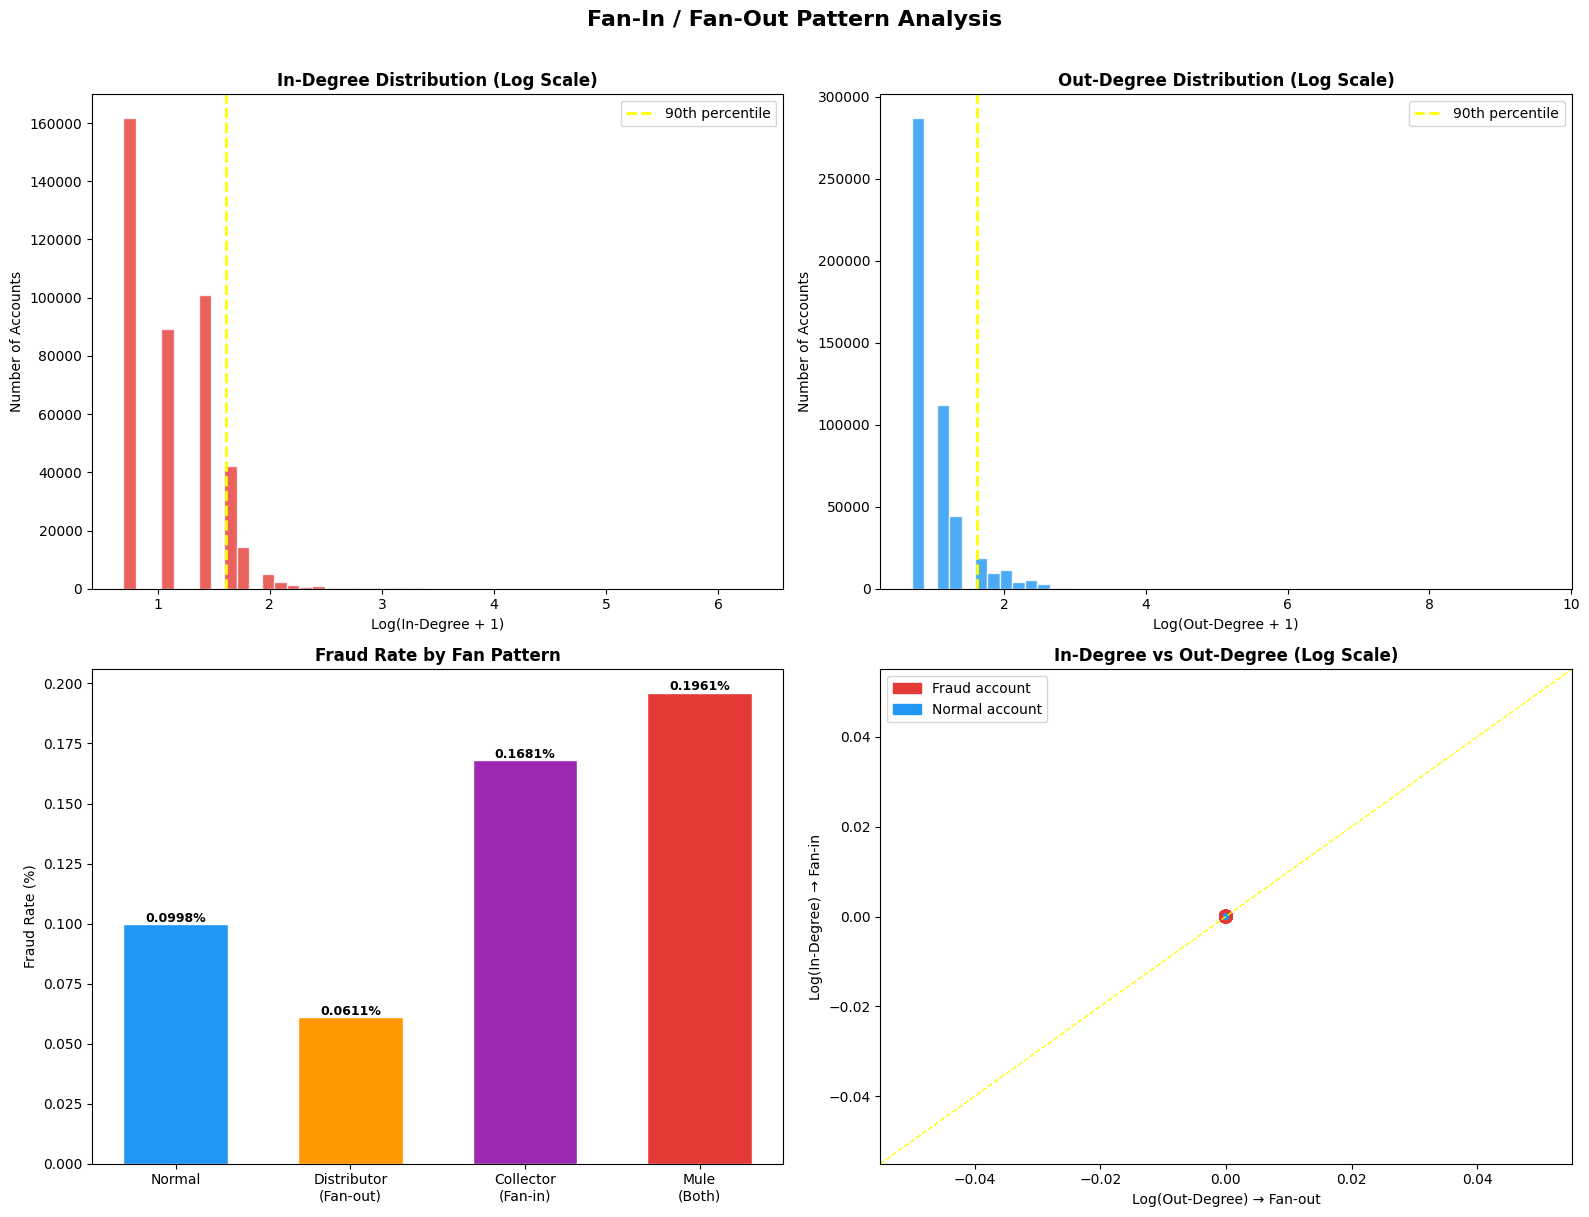

Fan pattern chart saved!


In [17]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(
    'Fan-In / Fan-Out Pattern Analysis',
    fontsize=16, fontweight='bold', y=1.01
)

# ── Chart 1: In-degree distribution ──────────────────────
in_deg_vals = list(in_degree.values())
axes[0,0].hist(
    np.log1p(in_deg_vals),
    bins=50, color='#E53935',
    edgecolor='white', alpha=0.8
)
axes[0,0].set_title('In-Degree Distribution (Log Scale)', fontweight='bold')
axes[0,0].set_xlabel('Log(In-Degree + 1)')
axes[0,0].set_ylabel('Number of Accounts')
axes[0,0].axvline(
    np.log1p(np.percentile(in_deg_vals, 90)),
    color='yellow', linestyle='--', linewidth=2,
    label='90th percentile'
)
axes[0,0].legend()

# ── Chart 2: Out-degree distribution ─────────────────────
out_deg_vals = list(out_degree.values())
axes[0,1].hist(
    np.log1p(out_deg_vals),
    bins=50, color='#2196F3',
    edgecolor='white', alpha=0.8
)
axes[0,1].set_title('Out-Degree Distribution (Log Scale)', fontweight='bold')
axes[0,1].set_xlabel('Log(Out-Degree + 1)')
axes[0,1].set_ylabel('Number of Accounts')
axes[0,1].axvline(
    np.log1p(np.percentile(out_deg_vals, 90)),
    color='yellow', linestyle='--', linewidth=2,
    label='90th percentile'
)
axes[0,1].legend()

# ── Chart 3: Fan pattern fraud rate ──────────────────────
pattern_names = ['Normal', 'Distributor\n(Fan-out)', 'Collector\n(Fan-in)', 'Mule\n(Both)']
fraud_by_pattern = df.groupby('graph_fan_pattern')['Is Laundering'].mean() * 100
colors_pattern = ['#2196F3', '#FF9800', '#9C27B0', '#E53935']

bars = axes[1,0].bar(
    pattern_names[:len(fraud_by_pattern)],
    fraud_by_pattern.values,
    color=colors_pattern[:len(fraud_by_pattern)],
    edgecolor='white',
    width=0.6
)
axes[1,0].set_title('Fraud Rate by Fan Pattern', fontweight='bold')
axes[1,0].set_ylabel('Fraud Rate (%)')
for bar, rate in zip(bars, fraud_by_pattern.values):
    axes[1,0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.001,
        f'{rate:.4f}%',
        ha='center', fontsize=9, fontweight='bold'
    )

# ── Chart 4: In vs Out degree scatter ────────────────────
sample_nodes = list(G.nodes())[:2000]
in_vals  = [in_degree.get(n, 0)  for n in sample_nodes]
out_vals = [out_degree.get(n, 0) for n in sample_nodes]

# Check if node is fraud
is_fraud_node = [
    1 if n in fraud_set else 0
    for n in sample_nodes
]

colors_scatter = [
    '#E53935' if f else '#2196F3'
    for f in is_fraud_node
]
sizes_scatter = [
    80 if f else 10
    for f in is_fraud_node
]

axes[1,1].scatter(
    np.log1p(out_vals),
    np.log1p(in_vals),
    c=colors_scatter,
    s=sizes_scatter,
    alpha=0.6
)
axes[1,1].set_title('In-Degree vs Out-Degree (Log Scale)', fontweight='bold')
axes[1,1].set_xlabel('Log(Out-Degree) → Fan-out')
axes[1,1].set_ylabel('Log(In-Degree) → Fan-in')
axes[1,1].axline(
    (0,0), slope=1,
    color='yellow', linestyle='--',
    linewidth=1, label='Equal in/out'
)

legend_el = [
    mpatches.Patch(color='#E53935', label='Fraud account'),
    mpatches.Patch(color='#2196F3', label='Normal account'),
]
axes[1,1].legend(handles=legend_el)

plt.tight_layout()
plt.savefig('fan_pattern_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Fan pattern chart saved!")

## Circular flow and community visualization

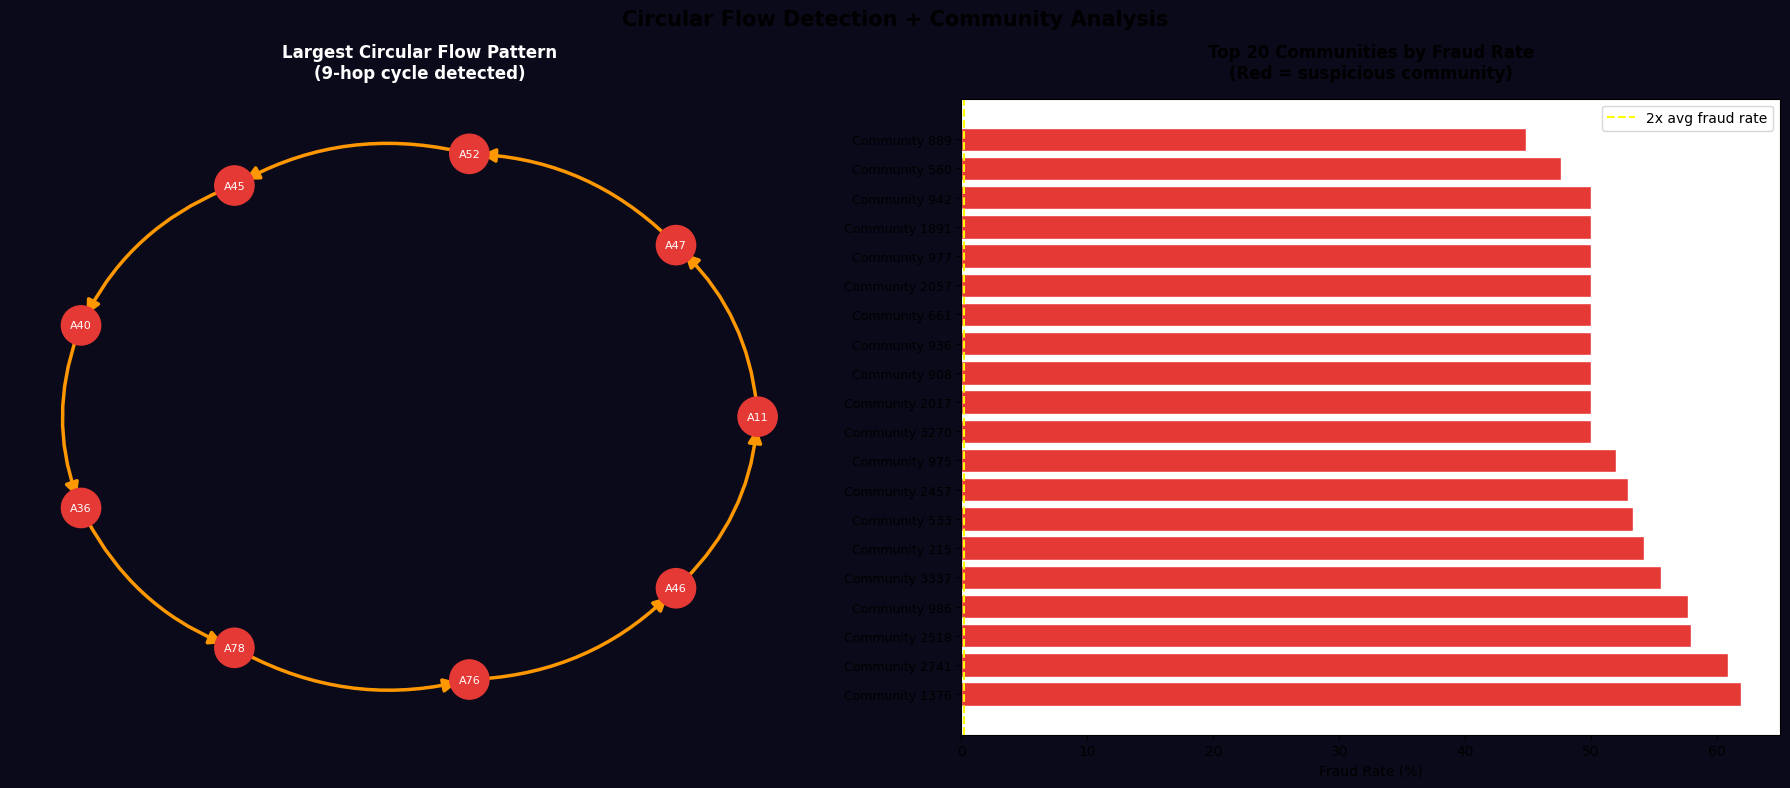

Circular flow and community chart saved!


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle(
    'Circular Flow Detection + Community Analysis',
    fontsize=15, fontweight='bold'
)

# ── Chart 1: Circular flow subgraph ──────────────────────
if cycles_found:
    # Take the largest cycle found
    largest_cycle = max(cycles_found, key=len)
    cycle_nodes_viz = largest_cycle[:15]  # max 15 nodes

    # Build cycle subgraph
    G_cycle = nx.DiGraph()
    for i in range(len(cycle_nodes_viz)):
        src = cycle_nodes_viz[i]
        dst = cycle_nodes_viz[(i+1) % len(cycle_nodes_viz)]
        if G.has_edge(src, dst):
            G_cycle.add_edge(
                src, dst,
                weight=G[src][dst].get('weight', 1)
            )

    # Circular layout for cycle
    pos_cycle = nx.circular_layout(G_cycle)

    # Node colors for cycle
    nc_cycle = [
        '#E53935' if n in fraud_set
        else '#9C27B0'
        for n in G_cycle.nodes()
    ]

    axes[0].set_facecolor('#0A0A1A')
    nx.draw_networkx_nodes(
        G_cycle, pos_cycle,
        node_color=nc_cycle,
        node_size=800,
        ax=axes[0]
    )
    nx.draw_networkx_edges(
        G_cycle, pos_cycle,
        edge_color='#FF9800',
        width=2.5,
        arrows=True,
        arrowsize=20,
        connectionstyle='arc3,rad=0.2',
        ax=axes[0]
    )
    nx.draw_networkx_labels(
        G_cycle, pos_cycle,
        labels={n: f"A{n[-2:]}" for n in G_cycle.nodes()},
        font_size=8,
        font_color='white',
        ax=axes[0]
    )
    axes[0].set_facecolor('#0A0A1A')
    axes[0].set_title(
        f'Largest Circular Flow Pattern\n'
        f'({len(largest_cycle)}-hop cycle detected)',
        fontweight='bold', color='white', pad=15
    )
    axes[0].axis('off')
    axes[0].figure.set_facecolor('#0A0A1A')

# ── Chart 2: Community fraud rate bar chart ───────────────
top_communities = df[
    df['graph_community_id'] >= 0
].groupby('graph_community_id').agg(
    fraud_rate=('Is Laundering', 'mean'),
    txn_count=('Is Laundering', 'count')
).sort_values('fraud_rate', ascending=False).head(20)

top_communities['fraud_rate'] = top_communities['fraud_rate'] * 100

colors_comm = [
    '#E53935' if r > avg_fraud_rate * 100 * 2
    else '#2196F3'
    for r in top_communities['fraud_rate']
]

axes[1].barh(
    range(len(top_communities)),
    top_communities['fraud_rate'],
    color=colors_comm,
    edgecolor='white'
)
axes[1].set_yticks(range(len(top_communities)))
axes[1].set_yticklabels(
    [f"Community {i}" for i in top_communities.index],
    fontsize=9
)
axes[1].axvline(
    x=avg_fraud_rate * 100 * 2,
    color='yellow', linestyle='--',
    linewidth=1.5, label='2x avg fraud rate'
)
axes[1].set_title(
    'Top 20 Communities by Fraud Rate\n(Red = suspicious community)',
    fontweight='bold', pad=15
)
axes[1].set_xlabel('Fraud Rate (%)')
axes[1].legend()

plt.tight_layout()
plt.savefig('circular_community.png', dpi=150, bbox_inches='tight')
plt.show()
print("Circular flow and community chart saved!")

## Graph metrices visualization

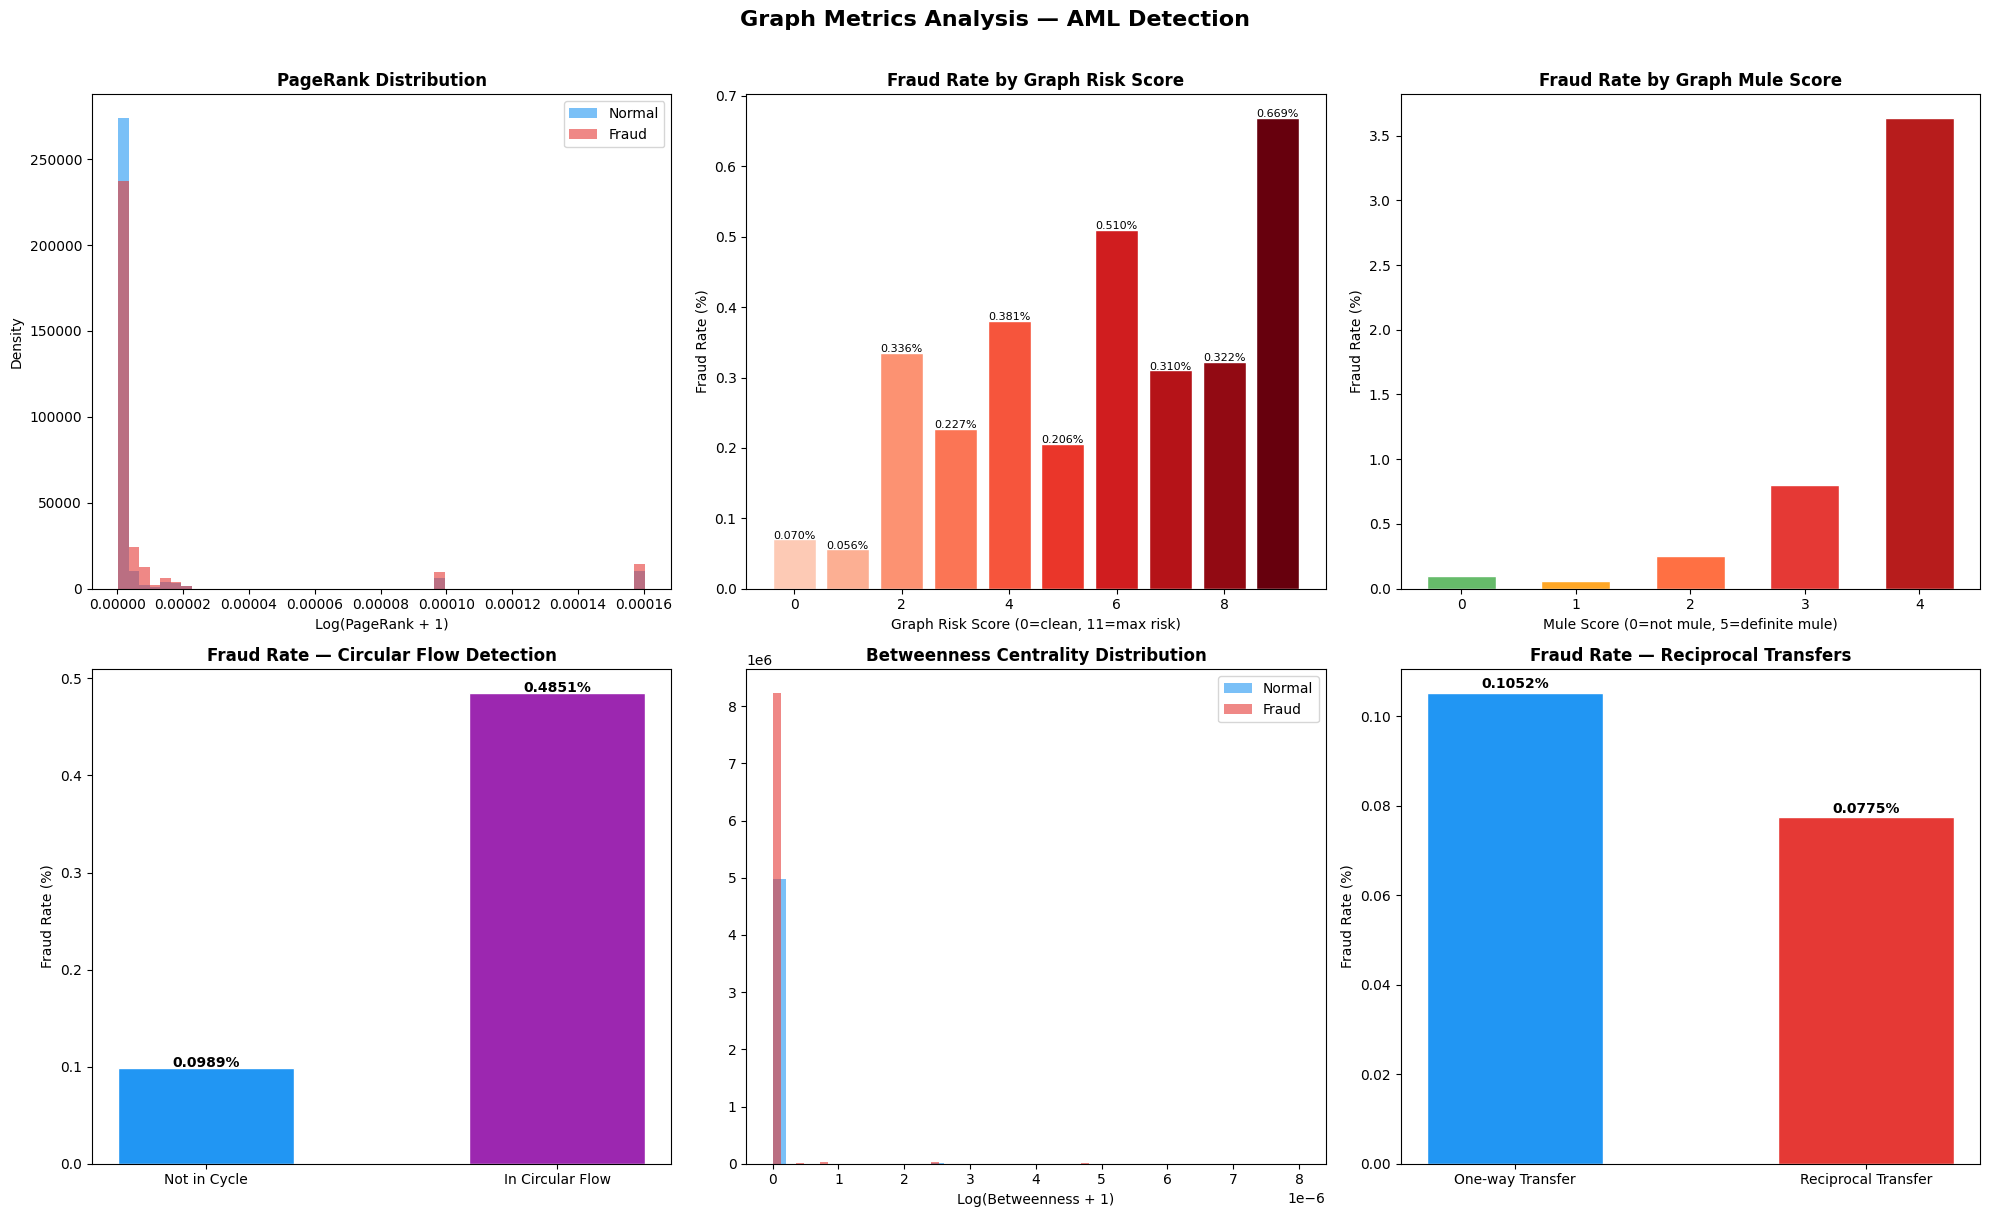

Graph metrics chart saved!


In [19]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle(
    'Graph Metrics Analysis — AML Detection',
    fontsize=16, fontweight='bold', y=1.01
)

# ── Chart 1: PageRank fraud vs normal ────────────────────
axes[0,0].hist(
    np.log1p(df[df['Is Laundering']==0]['graph_pagerank_sender']),
    bins=50, color='#2196F3', alpha=0.6,
    label='Normal', density=True
)
axes[0,0].hist(
    np.log1p(df[df['Is Laundering']==1]['graph_pagerank_sender']),
    bins=50, color='#E53935', alpha=0.6,
    label='Fraud', density=True
)
axes[0,0].set_title('PageRank Distribution', fontweight='bold')
axes[0,0].set_xlabel('Log(PageRank + 1)')
axes[0,0].set_ylabel('Density')
axes[0,0].legend()

# ── Chart 2: Graph risk score vs fraud rate ───────────────
risk_fraud = df.groupby('graph_risk_score')['Is Laundering'].mean() * 100
risk_count = df.groupby('graph_risk_score').size()

bars = axes[0,1].bar(
    risk_fraud.index,
    risk_fraud.values,
    color=plt.cm.Reds(
        np.linspace(0.2, 1.0, len(risk_fraud))
    ),
    edgecolor='white'
)
axes[0,1].set_title('Fraud Rate by Graph Risk Score', fontweight='bold')
axes[0,1].set_xlabel('Graph Risk Score (0=clean, 11=max risk)')
axes[0,1].set_ylabel('Fraud Rate (%)')
for bar, rate in zip(bars, risk_fraud.values):
    if rate > 0:
        axes[0,1].text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.001,
            f'{rate:.3f}%',
            ha='center', fontsize=8
        )

# ── Chart 3: Mule score distribution ─────────────────────
mule_fraud_rate = df.groupby('graph_mule_score')['Is Laundering'].mean() * 100
colors_mule = ['#66BB6A','#FFA726','#FF7043','#E53935','#B71C1C','#7B1FA2']

axes[0,2].bar(
    mule_fraud_rate.index,
    mule_fraud_rate.values,
    color=colors_mule[:len(mule_fraud_rate)],
    edgecolor='white',
    width=0.6
)
axes[0,2].set_title('Fraud Rate by Graph Mule Score', fontweight='bold')
axes[0,2].set_xlabel('Mule Score (0=not mule, 5=definite mule)')
axes[0,2].set_ylabel('Fraud Rate (%)')

# ── Chart 4: Cycle vs non-cycle fraud rate ────────────────
cycle_fraud = df.groupby('is_in_cycle')['Is Laundering'].mean() * 100
axes[1,0].bar(
    ['Not in Cycle', 'In Circular Flow'],
    cycle_fraud.values,
    color=['#2196F3', '#9C27B0'],
    edgecolor='white', width=0.5
)
axes[1,0].set_title('Fraud Rate — Circular Flow Detection', fontweight='bold')
axes[1,0].set_ylabel('Fraud Rate (%)')
for i, rate in enumerate(cycle_fraud.values):
    axes[1,0].text(
        i, rate + 0.001,
        f'{rate:.4f}%',
        ha='center', fontweight='bold'
    )

# ── Chart 5: Betweenness vs fraud ─────────────────────────
axes[1,1].hist(
    np.log1p(df[df['Is Laundering']==0]['graph_betweenness']),
    bins=40, color='#2196F3', alpha=0.6,
    label='Normal', density=True
)
axes[1,1].hist(
    np.log1p(df[df['Is Laundering']==1]['graph_betweenness']),
    bins=40, color='#E53935', alpha=0.6,
    label='Fraud', density=True
)
axes[1,1].set_title('Betweenness Centrality Distribution', fontweight='bold')
axes[1,1].set_xlabel('Log(Betweenness + 1)')
axes[1,1].legend()

# ── Chart 6: Reciprocal transfer fraud rate ───────────────
recip_fraud = df.groupby('graph_is_reciprocal')['Is Laundering'].mean() * 100
axes[1,2].bar(
    ['One-way Transfer', 'Reciprocal Transfer'],
    recip_fraud.values,
    color=['#2196F3', '#E53935'],
    edgecolor='white', width=0.5
)
axes[1,2].set_title('Fraud Rate — Reciprocal Transfers', fontweight='bold')
axes[1,2].set_ylabel('Fraud Rate (%)')
for i, rate in enumerate(recip_fraud.values):
    axes[1,2].text(
        i, rate + 0.001,
        f'{rate:.4f}%',
        ha='center', fontweight='bold'
    )

plt.tight_layout()
plt.savefig('graph_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graph metrics chart saved!")

## Save graph features to dataset

In [20]:
# ── All new graph features ─────────────────────────────────
graph_feature_cols = [
    'graph_in_degree',
    'graph_out_degree',
    'graph_in_degree_weighted',
    'graph_out_degree_weighted',
    'graph_total_degree',
    'graph_degree_ratio',
    'graph_pagerank_sender',
    'graph_pagerank_receiver',
    'graph_pagerank_max',
    'graph_fan_in_score',
    'graph_fan_out_score',
    'graph_fan_in_count',
    'graph_fan_out_count',
    'graph_fan_ratio',
    'graph_fan_pattern',
    'is_in_cycle',
    'graph_community_id',
    'graph_community_fraud_rate',
    'is_suspicious_community',
    'graph_mule_score',
    'graph_is_mule',
    'graph_betweenness',
    'graph_clustering',
    'graph_closeness',
    'graph_is_reciprocal',
    'graph_risk_score',
]

# Verify all columns exist
graph_feature_cols = [
    c for c in graph_feature_cols if c in df.columns
]

# Add graph features to the main featured dataset
df_with_graph = df.copy()

# Save
os.makedirs('featured', exist_ok=True)
df_with_graph.to_csv(
    'featured/featured_with_graph.csv', index=False
)

# Save graph object for later use
import pickle
with open('featured/transaction_graph.pkl', 'wb') as f:
    pickle.dump(G, f)

# Save graph feature names
joblib.dump(
    graph_feature_cols,
    'featured/graph_feature_names.pkl'
)

print("Graph features saved!")
print(f"\nTotal graph features : {len(graph_feature_cols)}")
print(f"Dataset shape        : {df_with_graph.shape}")
print(f"\nGraph feature list:")
for i, col in enumerate(graph_feature_cols, 1):
    print(f"  {i:2}. {col}")

Graph features saved!

Total graph features : 23
Dataset shape        : (5078336, 56)

Graph feature list:
   1. graph_in_degree
   2. graph_out_degree
   3. graph_in_degree_weighted
   4. graph_out_degree_weighted
   5. graph_total_degree
   6. graph_degree_ratio
   7. graph_pagerank_sender
   8. graph_pagerank_receiver
   9. graph_pagerank_max
  10. graph_fan_in_score
  11. graph_fan_out_score
  12. graph_fan_pattern
  13. is_in_cycle
  14. graph_community_id
  15. graph_community_fraud_rate
  16. is_suspicious_community
  17. graph_mule_score
  18. graph_is_mule
  19. graph_betweenness
  20. graph_clustering
  21. graph_closeness
  22. graph_is_reciprocal
  23. graph_risk_score


In [22]:
# ============================================================
# SAVE GRAPH ANALYSIS OUTPUTS
# ============================================================

import os
import pickle
import joblib
import pandas as pd
import numpy as np

print("=" * 60)
print("SAVING GRAPH ANALYSIS OUTPUTS")
print("=" * 60)

# ------------------------------------------------------------
# 1. Define graph feature columns
# ------------------------------------------------------------

graph_feature_cols = [
    'graph_in_degree',
    'graph_out_degree',
    'graph_in_degree_weighted',
    'graph_out_degree_weighted',
    'graph_total_degree',
    'graph_degree_ratio',
    'graph_pagerank_sender',
    'graph_pagerank_receiver',
    'graph_pagerank_max',
    'graph_fan_in_score',
    'graph_fan_out_score',
    'graph_fan_in_count',
    'graph_fan_out_count',
    'graph_fan_ratio',
    'graph_fan_pattern',
    'is_in_cycle',
    'graph_community_id',
    'graph_community_fraud_rate',
    'is_suspicious_community',
    'graph_mule_score',
    'graph_is_mule',
    'graph_betweenness',
    'graph_clustering',
    'graph_closeness',
    'graph_is_reciprocal',
    'graph_risk_score'
]

# ------------------------------------------------------------
# 2. Keep only columns that actually exist
# ------------------------------------------------------------

graph_feature_cols = [
    c for c in graph_feature_cols
    if c in df.columns
]

print(
    f"\nGraph features available: "
    f"{len(graph_feature_cols)}"
)

# ------------------------------------------------------------
# 3. Create dataframe containing graph features
# ------------------------------------------------------------

df_with_graph = df.copy()

graph_features_df = df_with_graph[
    graph_feature_cols
].copy()

# ------------------------------------------------------------
# 4. Create output directories
# ------------------------------------------------------------

os.makedirs(
    "featured",
    exist_ok=True
)

os.makedirs(
    "results",
    exist_ok=True
)

# ------------------------------------------------------------
# 5. Save complete dataset with graph features
# ------------------------------------------------------------

df_with_graph.to_csv(
    "featured/featured_with_graph.csv",
    index=False
)

print(
    "\nSaved:"
    "\n  featured/featured_with_graph.csv"
)

# ------------------------------------------------------------
# 6. Save ONLY graph features
# ------------------------------------------------------------

graph_features_df.to_csv(
    "results/graph_features.csv",
    index=False
)

print(
    "  results/graph_features.csv"
)

# ------------------------------------------------------------
# 7. Save graph feature names
# ------------------------------------------------------------

joblib.dump(
    graph_feature_cols,
    "featured/graph_feature_names.pkl"
)

print(
    "  featured/graph_feature_names.pkl"
)

# ------------------------------------------------------------
# 8. Save NetworkX graph object
# ------------------------------------------------------------

with open(
    "featured/transaction_graph.pkl",
    "wb"
) as f:

    pickle.dump(
        G,
        f
    )

print(
    "  featured/transaction_graph.pkl"
)

# ============================================================
# COMMUNITY ANALYSIS
# ============================================================

community_cols = [
    "graph_community_id",
    "graph_community_fraud_rate",
    "is_suspicious_community"
]

community_cols = [
    c for c in community_cols
    if c in df_with_graph.columns
]

if "graph_community_id" in df_with_graph.columns:

    community_analysis = (
        df_with_graph
        .groupby("graph_community_id")
        .agg(
            transaction_count=(
                "graph_community_id",
                "size"
            ),
            fraud_rate=(
                "graph_community_fraud_rate",
                "mean"
            ),
            suspicious_community=(
                "is_suspicious_community",
                "max"
            )
        )
        .reset_index()
    )

    community_analysis.to_csv(
        "results/graph_community_analysis.csv",
        index=False
    )

    print(
        "  results/graph_community_analysis.csv"
    )

else:

    print(
        "  Community analysis skipped "
        "(graph_community_id not found)"
    )


# ============================================================
# NODE / ACCOUNT ANALYSIS
# ============================================================

node_cols = [
    "graph_in_degree",
    "graph_out_degree",
    "graph_total_degree",
    "graph_pagerank_max",
    "graph_fan_in_count",
    "graph_fan_out_count",
    "graph_mule_score",
    "graph_is_mule",
    "graph_betweenness",
    "graph_clustering",
    "graph_closeness",
    "graph_is_reciprocal",
    "graph_risk_score"
]

node_cols = [
    c for c in node_cols
    if c in df_with_graph.columns
]

if len(node_cols) > 0:

    node_analysis = df_with_graph[
        node_cols
    ].copy()

    node_analysis.to_csv(
        "results/graph_node_analysis.csv",
        index=False
    )

    print(
        "  results/graph_node_analysis.csv"
    )

# ============================================================
# SUMMARY
# ============================================================

print("\n" + "=" * 60)
print("GRAPH FILES SAVED SUCCESSFULLY")
print("=" * 60)

print(
    f"\nTotal graph features : "
    f"{len(graph_feature_cols)}"
)

print(
    f"Dataset shape        : "
    f"{df_with_graph.shape}"
)

print(
    f"Graph nodes           : "
    f"{G.number_of_nodes():,}"
)

print(
    f"Graph edges           : "
    f"{G.number_of_edges():,}"
)

print("\nFiles available for future notebooks:")

print(
    "1. featured/featured_with_graph.csv"
)

print(
    "2. results/graph_features.csv"
)

print(
    "3. results/graph_community_analysis.csv"
)

print(
    "4. results/graph_node_analysis.csv"
)

print(
    "5. featured/transaction_graph.pkl"
)

print(
    "6. featured/graph_feature_names.pkl"
)

print("\nGraph analysis export completed!")

SAVING GRAPH ANALYSIS OUTPUTS

Graph features available: 23

Saved:
  featured/featured_with_graph.csv
  results/graph_features.csv
  featured/graph_feature_names.pkl
  featured/transaction_graph.pkl
  results/graph_community_analysis.csv
  results/graph_node_analysis.csv

GRAPH FILES SAVED SUCCESSFULLY

Total graph features : 23
Dataset shape        : (5078336, 56)
Graph nodes           : 515,080
Graph edges           : 1,015,736

Files available for future notebooks:
1. featured/featured_with_graph.csv
2. results/graph_features.csv
3. results/graph_community_analysis.csv
4. results/graph_node_analysis.csv
5. featured/transaction_graph.pkl
6. featured/graph_feature_names.pkl

Graph analysis export completed!


## Final summary

In [21]:
print("=" * 55)
print("NOTEBOOK 7 — GRAPH NETWORK ANALYSIS COMPLETE")
print("=" * 55)

print(f"""
GRAPH STATISTICS
  Total nodes (accounts)    : {G.number_of_nodes():,}
  Total edges (transactions): {G.number_of_edges():,}
  Graph density             : {nx.density(G):.8f}

FEATURES CREATED ({len(graph_feature_cols)} total)
  Degree metrics    : in/out degree, weighted, ratio
  PageRank          : sender, receiver, max
  Fan patterns      : fan-in, fan-out, classification
  Circular flows    : {len(cycles_found):,} cycles detected
  Communities       : {len(communities):,} detected
  Mule detection    : graph_mule_score, graph_is_mule
  Centrality        : betweenness, closeness, clustering
  Reciprocity       : mutual transfer flag
  Master score      : graph_risk_score (0-11)

VISUALISATIONS SAVED
  graph_network.png       ← main network graph
  fan_pattern_analysis.png
  circular_community.png
  graph_metrics.png

FILES SAVED
  featured/featured_with_graph.csv
  featured/transaction_graph.pkl
  featured/graph_feature_names.pkl

NEXT STEPS
  Notebook 8  → LSTM Deep Learning
  Notebook 9  → SHAP Explainability
  Notebook 10 → Risk Scoring Engine
               (uses XGBoost + Graph + LSTM scores)
""")

NOTEBOOK 7 — GRAPH NETWORK ANALYSIS COMPLETE

GRAPH STATISTICS
  Total nodes (accounts)    : 515,080
  Total edges (transactions): 1,015,736
  Graph density             : 0.00000383

FEATURES CREATED (23 total)
  Degree metrics    : in/out degree, weighted, ratio
  PageRank          : sender, receiver, max
  Fan patterns      : fan-in, fan-out, classification
  Circular flows    : 812 cycles detected
  Communities       : 3,351 detected
  Mule detection    : graph_mule_score, graph_is_mule
  Centrality        : betweenness, closeness, clustering
  Reciprocity       : mutual transfer flag
  Master score      : graph_risk_score (0-11)

VISUALISATIONS SAVED
  graph_network.png       ← main network graph
  fan_pattern_analysis.png
  circular_community.png
  graph_metrics.png

FILES SAVED
  featured/featured_with_graph.csv
  featured/transaction_graph.pkl
  featured/graph_feature_names.pkl

NEXT STEPS
  Notebook 8  → LSTM Deep Learning
  Notebook 9  → SHAP Explainability
  Notebook 10 → Ris